## Завдання 1
Підготуйте датасет Chest X-Ray Pneumonia.
 - Завантажте зображення.
 - Виконайте resize (224×224) і нормалізацію.
 - Розділіть дані на train/test.



In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(
    root='chest_xray',
    transform=transform
)

print("Кількість зображень:", len(dataset))
print("Класи:", dataset.classes)

Кількість зображень: 5856
Класи: ['test', 'train']


In [2]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 4684
Test size: 1172


In [3]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [4]:
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


## Завдання 2
Використовуйте переднавчену модель ResNet18.
 - Заморозьте згорткові шари.
 - Замініть класифікатор на новий (Linear(512, 2)).
 - Функція втрат: CrossEntropyLoss.
 - Оптимізатор: Adam (lr=0.0001).
 - Навчіть 5 епох.



In [5]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [6]:
for param in model.parameters():
    param.requires_grad = False

In [7]:
model.fc = nn.Linear(512, 2)

for param in model.fc.parameters():
    param.requires_grad = True

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

In [10]:
epochs = 5

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {running_loss:.4f} "
          f"Accuracy: {accuracy:.2f}%")

Epoch [1/5] Loss: 63.3858 Accuracy: 83.18%
Epoch [2/5] Loss: 53.0935 Accuracy: 88.94%
Epoch [3/5] Loss: 52.5800 Accuracy: 88.94%
Epoch [4/5] Loss: 52.0246 Accuracy: 88.94%
Epoch [5/5] Loss: 51.4049 Accuracy: 88.94%


## Завдання 3
Перевірте якість моделі.
 - Порахуйте Accuracy, Precision, Recall і F1-score.
 - Побудуйте confusion matrix.
 - Збережіть навчену модель у файл pneumonia_resnet18.pth.



In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [12]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.909556313993174
Precision: 0.909556313993174
Recall: 1.0
F1-score: 0.9526362823949955


In [13]:
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[   0  106]
 [   0 1066]]


## Завдання 4
Зробіть візуалізацію результатів.
 - Відобразіть 8 випадкових зображень із тестової вибірки.
 - Підпишіть передбачений і реальний клас.
 - Збережіть графік під іменем pneumonia_predictions.png.
 - Зробіть короткий висновок: наскільки модель готова до впровадження?



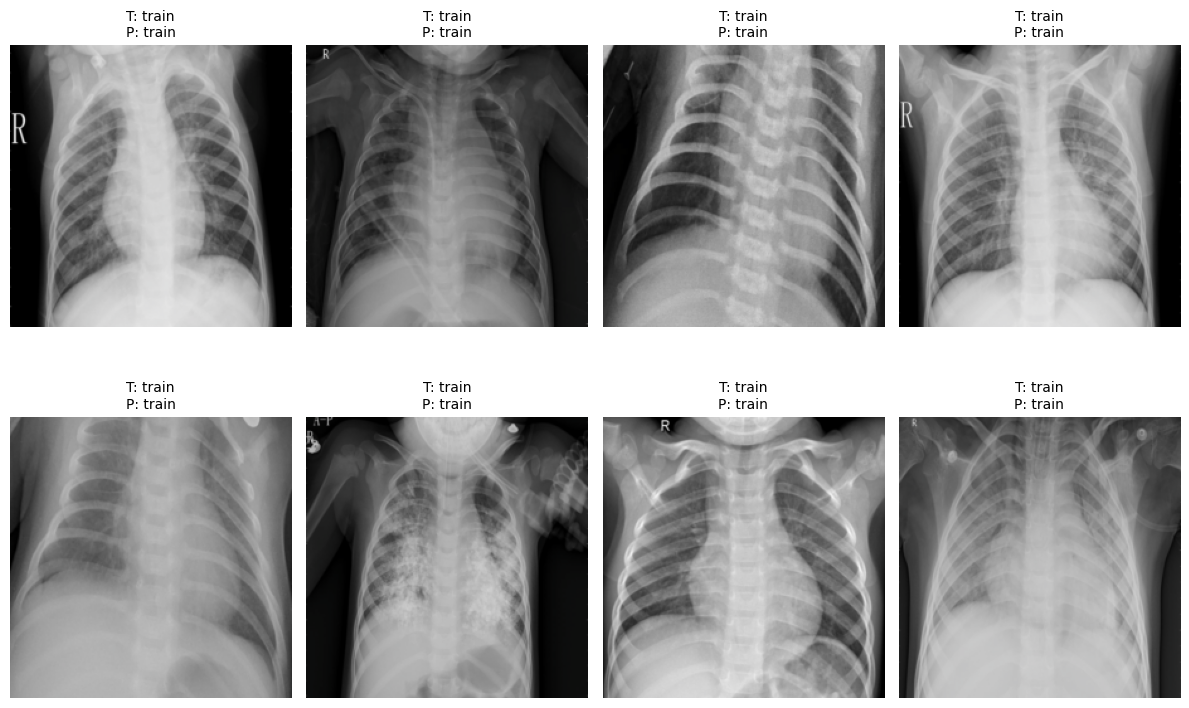

In [17]:
model.eval()

import matplotlib.pyplot as plt
import random
import numpy as np

indices = random.sample(range(len(test_dataset)), 8)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    image, label = test_dataset[idx]

    input_img = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    pred = pred.item()

    img = image.permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)

    true_class = test_dataset.dataset.classes[label]
    pred_class = test_dataset.dataset.classes[pred]

    plt.title(f"T: {true_class}\nP: {pred_class}", fontsize=10)
    plt.axis("off")

plt.tight_layout()

In [ ]:
plt.savefig("pneumonia_predictions.png")
plt.show()

print("Saved: pneumonia_predictions.png")